# 03 - Phân tích lỗi

**Giai đoạn trong pipeline:** ... -> Đánh giá trên tập test cuối cùng -> **Ma trận nhầm lẫn ->
Phân tích lỗi phân loại sai** -> So sánh mô hình -> Kết luận

Mô hình cuối cùng được chọn: **`cnn/run_002`** (CNN, dropout 0.5) - được chọn trong
`02_training_and_comparison.ipynb` dựa trên validation accuracy (0.9262, cao nhất trong ba
lần chạy chính thức). Notebook này nạp các artifact đánh giá trên tập test đã lưu của lần
chạy đó (được tạo ra bởi `scripts/evaluate.py`) - nó không chạy lại suy luận (inference) từ
đầu.


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import json

import numpy as np
import pandas as pd
from torchvision import datasets

from src.dataset import CLASS_NAMES, DATA_DIR
from src.evaluation import find_top_confusion_pairs
from src.visualization import plot_confusion_matrix, plot_misclassified_grid

FINAL_RUN_DIR = PROJECT_ROOT / "runs" / "cnn" / "run_002"

## Số liệu kiểm tra cuối cùng


In [2]:
with open(FINAL_RUN_DIR / "metrics" / "final_metrics.json", "r") as f:
    final_metrics = json.load(f)

final_metrics

{'run_id': 'run_002',
 'model': 'cnn',
 'best_epoch': 12,
 'best_val_loss': 0.22818389320373536,
 'best_val_accuracy': 0.9261666666666667,
 'final_train_accuracy': 0.948,
 'final_val_accuracy': 0.9271666666666667,
 'test_accuracy': 0.9204}

## Ma trận nhầm lẫn (Confusion Matrix)

Được nạp từ `metrics/confusion_matrix.csv` (số lượng thực tế, hàng = nhãn thật, cột =
nhãn dự đoán), do `scripts/evaluate.py` lưu lại.


/var/folders/1g/g3jtxqks749bhmtvz3n303wc0000gn/T/ipykernel_11446/4010603457.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


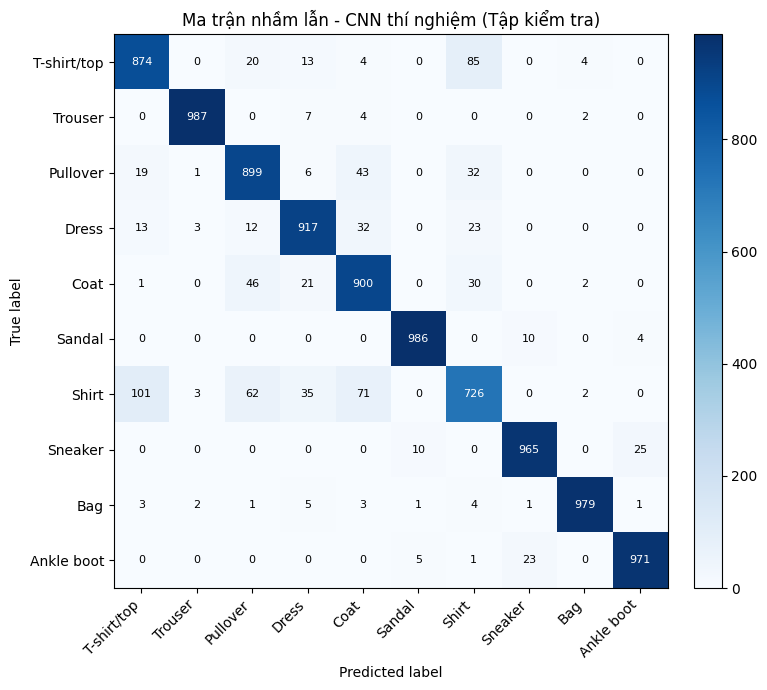

In [3]:
conf_matrix_df = pd.read_csv(FINAL_RUN_DIR / "metrics" / "confusion_matrix.csv", index_col=0)
conf_matrix = conf_matrix_df.values

fig = plot_confusion_matrix(conf_matrix, CLASS_NAMES, title="Ma trận nhầm lẫn - CNN thí nghiệm (Tập kiểm tra)")
fig.show()


## Precision / Recall / F1 theo từng lớp


In [4]:
per_class_df = pd.read_csv(FINAL_RUN_DIR / "metrics" / "per_class_metrics.csv")
per_class_df.sort_values("f1_score")

,class,precision,recall,f1_score,support
6,Shirt,0.805771,0.726,0.763809,1000
0,T-shirt/top,0.864491,0.874,0.869219,1000
4,Coat,0.851466,0.900,0.875061,1000
2,Pullover,0.864423,0.899,0.881373,1000
3,Dress,0.913347,0.917,0.915170,1000
7,Sneaker,0.965966,0.965,0.965483,1000
9,Ankle boot,0.970030,0.971,0.970515,1000
8,Bag,0.989889,0.979,0.984414,1000
5,Sandal,0.984032,0.986,0.985015,1000
1,Trouser,0.990964,0.987,0.988978,1000


## Các cặp nhầm lẫn lớn nhất

Được xác định trực tiếp từ ma trận nhầm lẫn thực tế (không có giả định nào về việc lớp nào
bị nhầm lẫn được viết cứng trong code).


In [5]:
top_pairs_df = find_top_confusion_pairs(conf_matrix, CLASS_NAMES, top_k=8)
top_pairs_df

,true_label,predicted_label,count
0,Shirt,T-shirt/top,101
1,T-shirt/top,Shirt,85
2,Shirt,Coat,71
3,Shirt,Pullover,62
4,Coat,Pullover,46
5,Pullover,Coat,43
6,Shirt,Dress,35
7,Dress,Coat,32


## Các lỗi tiêu biểu: nhãn thật so với dự đoán, kèm độ tin cậy

`metrics/misclassified.csv` lưu `sample_index` (vị trí của mẫu trong tập test chính thức,
vì `test_loader` dùng `shuffle=False`), `true_label`, `predicted_label`, và `confidence`.
Chúng ta nạp lại các ảnh test gốc (chưa qua biến đổi) theo index để trực quan hóa chúng.


/var/folders/1g/g3jtxqks749bhmtvz3n303wc0000gn/T/ipykernel_11446/1308086729.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Tổng số mẫu test bị phân loại sai: 796 trên tổng số 10000


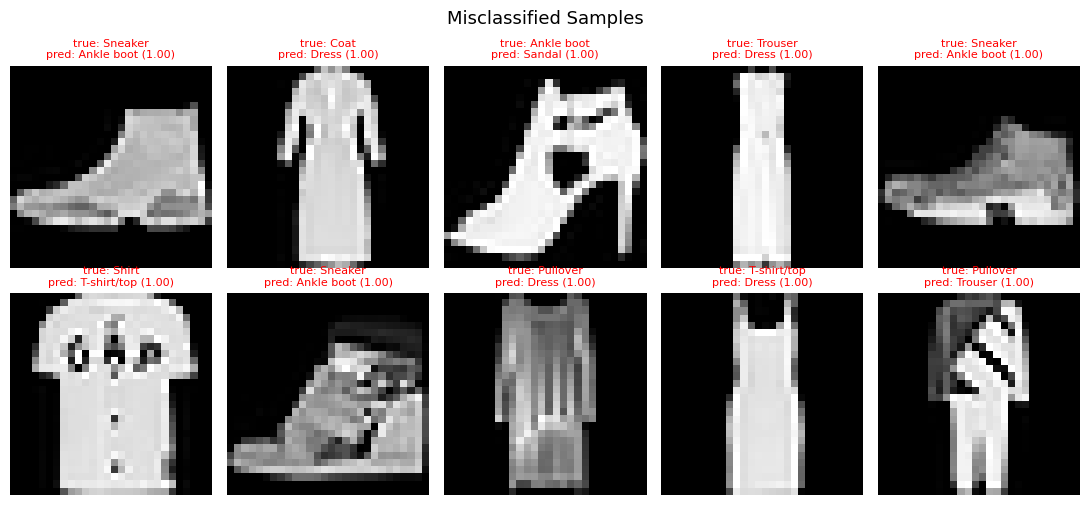

In [6]:
misclassified_df = pd.read_csv(FINAL_RUN_DIR / "metrics" / "misclassified.csv")
print(f"Tổng số mẫu test bị phân loại sai: {len(misclassified_df)} trên tổng số 10000")

raw_test = datasets.FashionMNIST(root=str(DATA_DIR), train=False, download=True)

# Sắp xếp giảm dần theo độ tin cậy: những lỗi mà mô hình "tự tin nhưng sai" thường là
# những trường hợp thú vị nhất để xem xét.
top_confident_errors = misclassified_df.sort_values("confidence", ascending=False).head(10)

images = np.stack([np.array(raw_test[i][0]) for i in top_confident_errors["sample_index"]])[:, None, :, :]
true_labels = top_confident_errors["true_label"].to_numpy()
predicted_labels = top_confident_errors["predicted_label"].to_numpy()
confidences = top_confident_errors["confidence"].to_numpy()

fig = plot_misclassified_grid(images, true_labels, predicted_labels, confidences, CLASS_NAMES, n=10)
fig.show()


## Xem xét cặp nhầm lẫn lớn nhất

Ô lệnh phía trên (`top_pairs_df`) đã xác định các cặp nhầm lẫn lớn nhất thực tế cho mô hình
này. Bên dưới, chúng ta lấy ra các mẫu bị phân loại sai thực tế cho cặp lớn nhất và trực
quan hóa chúng, để kết nối con số nhầm lẫn với hình ảnh thực tế.


Cặp nhầm lẫn lớn nhất: nhãn thật='Shirt' dự đoán='T-shirt/top' (số lượng=101)


/var/folders/1g/g3jtxqks749bhmtvz3n303wc0000gn/T/ipykernel_11446/2120328638.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


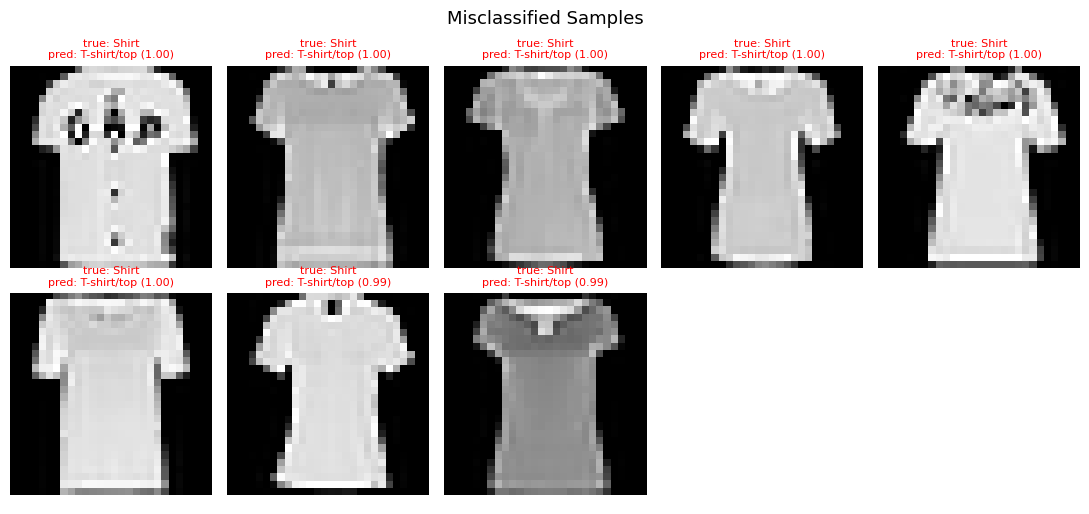

In [7]:
class_to_idx = {name: idx for idx, name in enumerate(CLASS_NAMES)}
top_pair = top_pairs_df.iloc[0]
true_idx = class_to_idx[top_pair["true_label"]]
pred_idx = class_to_idx[top_pair["predicted_label"]]

print(f"Cặp nhầm lẫn lớn nhất: nhãn thật='{top_pair['true_label']}' dự đoán='{top_pair['predicted_label']}' "
      f"(số lượng={top_pair['count']})")

pair_mask = (misclassified_df["true_label"] == true_idx) & (misclassified_df["predicted_label"] == pred_idx)
pair_examples = misclassified_df[pair_mask].sort_values("confidence", ascending=False).head(8)

images = np.stack([np.array(raw_test[i][0]) for i in pair_examples["sample_index"]])[:, None, :, :]
true_labels = pair_examples["true_label"].to_numpy()
predicted_labels = pair_examples["predicted_label"].to_numpy()
confidences = pair_examples["confidence"].to_numpy()

fig = plot_misclassified_grid(images, true_labels, predicted_labels, confidences, CLASS_NAMES, n=len(pair_examples))
fig.show()


## Thảo luận: các nguyên nhân có thể gây nhầm lẫn

Hãy chạy notebook này từ đầu đến cuối và xem kết quả thực tế của `top_pairs_df` ở trên
trước khi đọc phần diễn giải bên dưới - nó cần khớp với các lớp thực sự bị nhầm lẫn đối
với mô hình/lần chạy này (đừng giả định nó luôn là cùng một cặp).

Đối với mô hình CNN thí nghiệm trên bộ dữ liệu này, các nhầm lẫn chủ yếu xảy ra giữa các
lớp trang phục phần thân trên: **Shirt**, **T-shirt/top**, **Pullover**, và **Coat**. Điều
này là dễ hiểu xét về mặt tương đồng hình ảnh:

- Cả bốn lớp đều có silhouette gần giống nhau (thân + tay áo ngắn/dài) ở độ phân giải
  28x28 ảnh xám, nơi các chi tiết nhỏ như cổ áo, cúc áo, hay chất liệu vải gần như không
  nhìn thấy được.
- **Shirt so với T-shirt/top**: khác nhau chủ yếu ở độ dài tay áo và cổ áo, một khác biệt
  khá tinh tế ở độ phân giải thấp.
- **Coat so với Pullover**: khác nhau chủ yếu ở việc trang phục có mặt trước mở hay không,
  điều này có thể mơ hồ khi áo khoác đóng kín hoặc tư thế che khuất phần trước.
- Các lớp có silhouette đặc trưng rõ ràng (Trouser, Bag, Sandal, Ankle boot) có rất ít
  nhầm lẫn trong ma trận ở trên, ủng hộ ý tưởng rằng nhầm lẫn ở đây đến từ silhouette/kết
  cấu tương đồng, chứ không phải do mô hình hoạt động kém nói chung.

Điều này gợi ý rằng các cải thiện tiếp theo có khả năng đến từ việc tăng độ phân giải đầu
vào hoặc thêm các đặc trưng nhạy với kết cấu (texture), thay vì chỉ đơn giản là huấn luyện
thêm epoch.
